## WINE QUALITY ANALISIS 

In this project, a wine quality analysis will be performed using machine learning techniques. A dataset containing information on different chemical characteristics of wine and its quality will be used, with the objective of building a model that can predict wine quality based on these characteristics

# Exploration Phase:
The dataset consists of 1,600 rows and 12 variables. Of these, 11 represent wine characteristics, while the final variable is the quality—with values ranging from 0 to 10—which serves as our target variable for prediction.

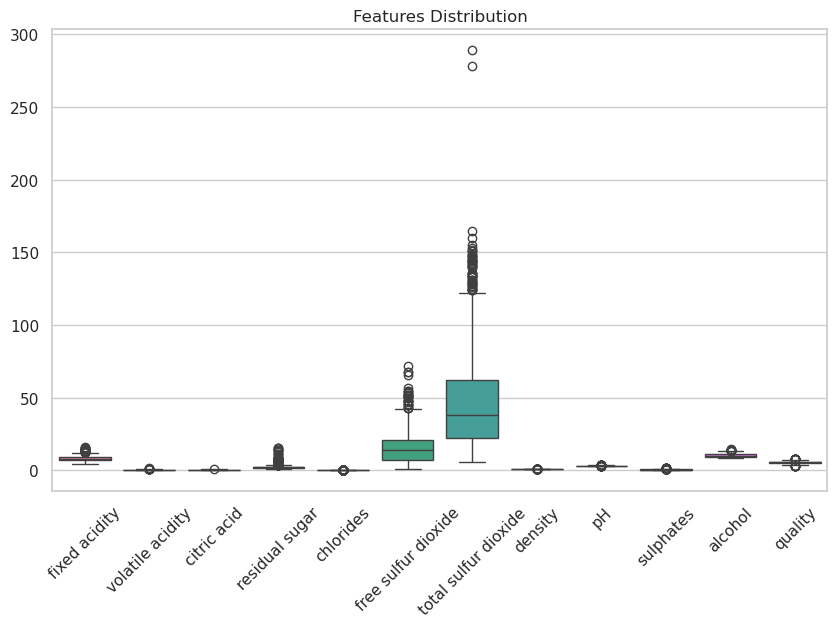

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

df = pd.read_csv('winequality.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)

plt.title('Features Distribution')
plt.xticks(rotation=45)
plt.show()


We observe a clear skewed distribution in the variables related to sulfur dioxide, which requires us to standardize the features when building the model.

Next, we will analyze the correlation between the variables to identify which ones are most strongly correlated with wine quality.

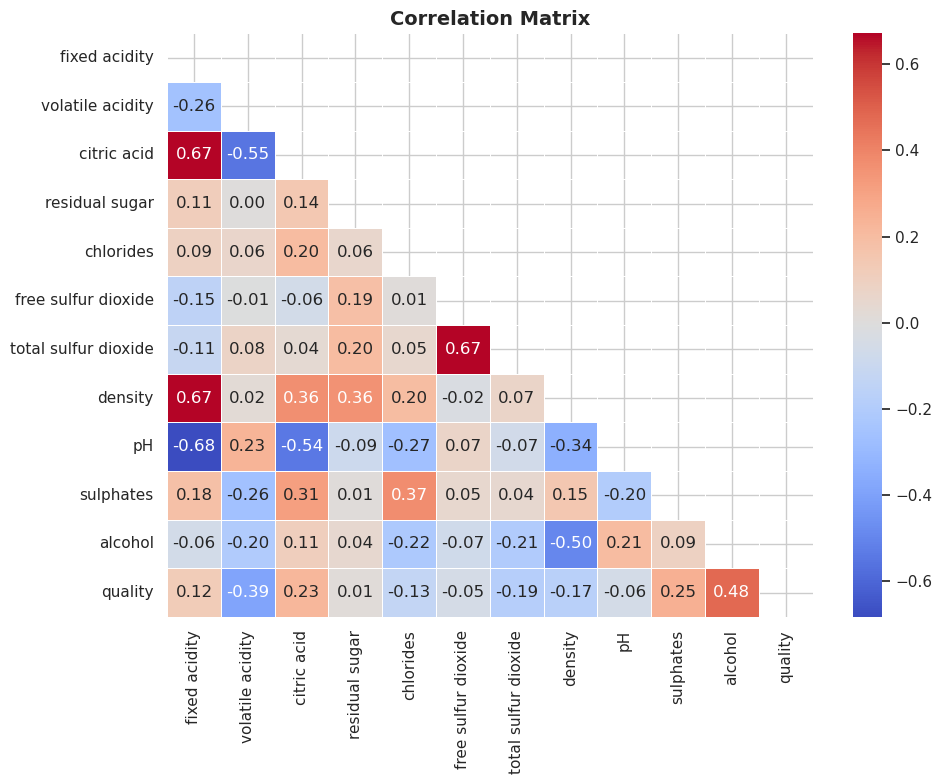

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



We see that alcohol is a strong predictor of wine quality, showing a correlation of 0.44, which indicates that wines with a higher ABV (alcohol by volume) tend to receive higher ratings. Conversely, factors like density and acidity are associated with lower wine quality.

# Modeling Phase

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = df.dropna()
df['quality'] = df['quality'].apply(lambda x: 'good' if x >= 7 else 'bad')

X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, ytrain, ytest = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(X_train)
Xtest_scaled = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000)
model.fit(Xtrain_scaled, ytrain)

y_pred_train = model.predict(Xtrain_scaled)
y_pred_final = model.predict(Xtest_scaled)
acc_train = accuracy_score(ytrain, y_pred_train)
acc_test = accuracy_score(ytest, y_pred_final)

print("Train accuracy: {:.4f}".format(acc_train))
print("Test accuracy: {:.4f}".format(acc_test))

Train accuracy: 0.8858
Test accuracy: 0.8656
